*2026 Spring DSAA 2011 Maching Learning*
## Lab Note 09
*Na Di, Changkai MAI, Chunming MA, Weikai YANG*  
*Hong Kong University of Science and Technology (Guangzhou)*

**Question 1**.  
1. Please write down the **calculation formulas** for the following **Clustering Metrics**，along with their intrinsic meanings.  
2. Please distinguish which are External Clustering Metrics and which are Internal Clustering Metrics.  

Metrics:

  (1) Purity  
  (2) Adjusted Rand Index  
  (3) Fowlkes-Mallows Index  
  (4) Adjusted Mutual Information  
  (5) V-measure  
  (6) Silhouette Coefficient  
  (7) Calinski-Harabaz Index  
  (8) Davies-Bouldin Index  
  (9) Dunn index  

**Solutions:**  
   （1）Purity
       $$\text{Purity} = \frac{1}{N} \sum_{k=1}^{K} \max_{j} \left| C_k \cap Y_j \right|$$
**Interpretation**:  
- Measures the fraction of data points in the dominant true class within each cluster.  
- Higher values (closer to 1) indicate better alignment between clusters and true labels.  

   （2）Adjusted Rand Index    
       $$\text{RI} = \frac{a + b}{C_2^n}$$
      $$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$
**Where:**
- $a$: Number of point pairs in the *same cluster* and *same class* (True Positives)
- $b$: Number of point pairs in *different clusters* and *different classes* (True Negatives)
- $\binom{n}{2} = \frac{n(n-1)}{2}$: Total number of possible point pairs
- $E[RI]$: Expected value of RI
- $\max(RI)$: Maximum possible value of RI
  
**Interpretation**:
- Measures similarity between clusters and true labels, adjusted for chance.      
- Range : [−1,1], where 1 = perfect match, 0 = random labeling.  

（3）Fowlkes-Mallows Index
  $$\text{FMI} = \frac{\text{TP}}{\sqrt{(\text{TP} + \text{FP})(\text{TP} + \text{FN})}}$$
**Where**:
- $\text{TP}$ (True Positives): Pairs of points in the *same cluster* and *same class*
- $\text{FP}$ (False Positives): Pairs in the *same cluster* but *different classes*
- $\text{FN}$ (False Negatives): Pairs in *different clusters* but *same class*

**Interpretation**:
- Measures the similarity between two clusterings (typically between computed clusters and true classes)

(4) Adjusted Mutual Information
$$\text{MI}(U, V) = \sum_{i=1}^{|U|} \sum_{j=1}^{|V|} P(i,j) \log \frac{P(i,j)}{P_U(i)P_V(j)}$$
$$E[\text{MI}] = \text{Expected value under random permutation}$$
$$H(U) = -\sum_{i=1}^{|U|} P_U(i) \log P_U(i) \\
   H(V) = -\sum_{j=1}^{|V|} P_V(j) \log P_V(j)$$
$$\text{AMI}(U, V) = \frac{\text{MI}(U, V) - E[\text{MI}]}{\max(H(U), H(V)) - E[\text{MI}]}$$
  **Where**:
   - $P(i,j)$: Joint probability of a point being in cluster $U_i$ and class $V_j$
   - $P_U(i)$, $P_V(j)$: Marginal probabilities
  
**Interpretation**:  
- AMI measures the agreement between two clusterings (typically between algorithm-generated clusters and ground truth labels), while **adjusting for chance** agreement that would occur randomly.

（5）V-measure
  $$\text{V-measure} = 2 \times \frac{\text{Homogeneity} \times \text{Completeness}}{\text{Homogeneity} + \text{Completeness}}$$

**Where:**

1. **Homogeneity** (each cluster contains only single class members):
$$
h = 1 - \frac{H(C|K)}{H(C)}
$$

2. **Completeness**(all members of a class are in same cluster):
$$
c = 1 - \frac{H(K|C)}{H(K)}
$$
- $K$: Algorithm-predicted clustering results
- $C$: Ground truth labels
  

（6）Silhouette Coefficient
  $$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$
  $$\text{Silhouette Score} = \frac{1}{N}\sum_{i=1}^{N} s(i)$$

**Where：**

**$a(i)$ - Intra-cluster Distance**
   *"How close $i$ is to its own cluster"*  
   $$
   a(i) = \frac{1}{|C_i| - 1} \sum_{j \in C_i, j \neq i} d(i,j)
   $$
   - $C_i$: Cluster containing point $i$  
   - $d(i,j)$: Distance between points $i$ and $j$  
   - *Interpretation*: Average distance to all other points in the same cluster  
   - *Example*: If $a(i)=0.5$, point $i$ is on average 0.5 units from its neighbors.

**$b(i)$ - Nearest-cluster Distance**  
   *"How far $i$ is from the next-best cluster"*  
   $$
   b(i) = \min_{k \neq C_i} \left( \frac{1}{|C_k|} \sum_{j \in C_k} d(i,j) \right)
   $$
   - $C_k$: All other clusters besides $C_i$  
   - *Interpretation*: Smallest average distance to any other cluster  
   - *Example*: If $b(i)=3.2$, the closest alternative cluster is 3.2 units away.

**Interpretation**:
- The **Silhouette Coefficient** is a metric used to evaluate the quality of clustering algorithms by measuring how well individual data points are grouped within their assigned clusters.

（7）Calinski–Harabasz Index

$$\text{CH} = \frac{\text{Tr}(B_k)}{\text{Tr}(W_k)} \times \frac{N - k}{k - 1}$$

**Where**:
- $N$: Total number of data points
- $k$: Number of clusters

$\text{Tr}(B_k)$: Trace of the between-cluster dispersion matrix
$$B_k = \mathrm{diag}(\mathbf n)\sum_{i = 1}^k(\mu_i - \mu)(\mu_i - \mu)^\top$$
$$\text{Tr}(B_k) = \sum_{i=1}^{k} n_i \|\mu_i - \mu\|^2$$
- $\mu$: Overall mean of the data
- $\Mu$: Vector of cluster centroids
- $\mu_k$: Centroid of cluster $k$
- $\mathbf n$: Vector of cluster sizes
- $n_k$: Size of cluster $k$

$\text{Tr}(W_k)$: Trace of the within-cluster dispersion matrix
$$W_k = \sum_{i=1}^{k} \sum_{x \in C_i} (x - \mu_i)(x - \mu_i)^\top$$
$$\text{Tr}(W_k) = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$


**Interpretation**:
- Measures the ratio of between-cluster variance to within-cluster variance.
- Higher values indicate better-defined clusters.

(8) Davies-Bouldin Index 
$$\text{DB} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{s_i + s_j}{d_{ij}} \right)$$
**Where**:
- $k$: Number of clusters
- $s_i$: Average distance between each point in cluster $i$ and the centroid of cluster $i$ (intra-cluster distance)
- $d_{ij}$: Distance between centroids of clusters $i$ and $j$

**Interpretation**:
- Measures the average similarity ratio of each cluster with its most similar cluster.
- Lower values indicate better clustering.

(9) Dunn index
$$\text{Dunn} = \frac{\min_{1 \leq i < j \leq k} d(C_i, C_j)}{\max_{1 \leq l \leq k} \delta(C_l)}$$

**Where**:
- $d(C_i, C_j)$: Minimum distance between points in clusters $C_i$ and $C_j$ (inter-cluster distance)
- $\delta(C_l)$: Maximum distance between points within cluster $C_l$ (intra-cluster distance)  

**Interpretation**:
- Measures the ratio of the minimum inter-cluster distance to the maximum intra-cluster distance.
- Higher values indicate better clustering.

**Question 2.** Implementation of Clustering Metrics

Please load the **DSAA2011-LA09-data1.csv** file to obtain the dataset, then complete the following tasks.  

**Task**  
1. Perform clustering using **K-means** by Sklearn.   
2. Implement the calculation of the aforementioned clustering metrics
3. Use the clustering metrics implemented to measure the clustering performance and compare them with the clustering metrics directly computed by scikit-learn. (**Note that purity and Dunn index are not provided by scikit-learn**).

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from math import log, comb

In [3]:
data = pd.read_csv('DSAA2011-LA09-data1.csv', sep='\t') 
data = data['x,y,label'].str.split(',', expand=True)  
data.columns = ['x', 'y', 'label'] 
data['x'] = data['x'].astype(float)  
data['y'] = data['y'].astype(float)  
true_labels = data['label'].astype(int).values  
X = data[['x', 'y']].values  

In [6]:
kmeans = KMeans(n_clusters=3)  
kmeans.fit(X)  
cluster_labels = kmeans.labels_          
centroids = kmeans.cluster_centers_

In [ ]:
#  Purity
def purity(y_true, y_pred):
    unique_true = np.unique(y_true)
    unique_pred = np.unique(y_pred)
    cont = np.zeros((len(unique_true), len(unique_pred)), dtype=int)
    
    true_to_idx = {v: i for i, v in enumerate(unique_true)}
    pred_to_idx = {v: j for j, v in enumerate(unique_pred)}
    
    for t, p in zip(y_true, y_pred):
        cont[true_to_idx[t], pred_to_idx[p]] += 1
    
    max_per_col = np.max(cont, axis=0)
    total = np.sum(cont)
    return np.sum(max_per_col) / total if total > 0 else 0.0

purity_score = purity(true_labels, cluster_labels)
print(purity_score)

0.7616666666666667


In [8]:
# ARI
from sklearn.metrics import adjusted_rand_score
def adjusted_rand_index(y_true, y_pred):

    unique_true = np.unique(y_true)
    unique_pred = np.unique(y_pred)
    cont = np.zeros((len(unique_true), len(unique_pred)), dtype=int)
    
    true_to_idx = {v: i for i, v in enumerate(unique_true)}
    pred_to_idx = {v: j for j, v in enumerate(unique_pred)}
    
    for t, p in zip(y_true, y_pred):
        cont[true_to_idx[t], pred_to_idx[p]] += 1
    
    n = np.sum(cont)
    
    def sum_comb(arr):
        return sum(comb(x, 2) for x in arr if x >= 2)
    
    sum_a = sum_comb(cont.sum(axis=1))  
    sum_b = sum_comb(cont.sum(axis=0))  
    sum_nij = sum_comb(cont.flatten())  
    
    expected = sum_a * sum_b / comb(n, 2) if comb(n, 2) > 0 else 0
    max_ = 0.5 * (sum_a + sum_b)
    
    if max_ - expected == 0:
        return 0.0
    return (sum_nij - expected) / (max_ - expected)

ari = adjusted_rand_index(true_labels, cluster_labels)
skl_ari = adjusted_rand_score(true_labels, cluster_labels)
print(ari)
print(skl_ari)

0.4561910209114972
0.4561910209114972


In [ ]:
# Fowlkes-Mallows Index
from sklearn.metrics import fowlkes_mallows_score
def fowlkes_mallows(y_true, y_pred):
    unique_true = np.unique(y_true)
    unique_pred = np.unique(y_pred)
    cont = np.zeros((len(unique_true), len(unique_pred)), dtype=int)
    
    true_to_idx = {v: i for i, v in enumerate(unique_true)}
    pred_to_idx = {v: j for j, v in enumerate(unique_pred)}
    
    for t, p in zip(y_true, y_pred):
        cont[true_to_idx[t], pred_to_idx[p]] += 1
    
    n = len(y_true)
    
    def sum_comb(arr):
        return sum(comb(x, 2) for x in arr if x >= 2)
    
    tp = sum_comb(cont.flatten())
    a = sum_comb(cont.sum(axis=1))  
    b = sum_comb(cont.sum(axis=0))  
    
    fp = b - tp
    fn = a - tp
    
    denominator = (tp + fp) * (tp + fn)
    if denominator <= 0:
        return 0.0
    return tp / np.sqrt(denominator)

fmi = fowlkes_mallows(true_labels, cluster_labels)
skl_fmi = fowlkes_mallows_score(true_labels, cluster_labels)
print(fmi)
print(skl_fmi)

0.6374667753477468
0.6374667753477468


In [12]:
# Adjusted Mutual Information
from sklearn.metrics import adjusted_mutual_info_score
def adjusted_mutual_info(y_true, y_pred):
    classes = np.unique(y_true)
    clusters = np.unique(y_pred)
    cont = np.zeros((len(classes), len(clusters)), dtype=int)
    
    class_to_idx = {c: i for i, c in enumerate(classes)}
    cluster_to_idx = {k: j for j, k in enumerate(clusters)}
    
    for true, pred in zip(y_true, y_pred):
        cont[class_to_idx[true], cluster_to_idx[pred]] += 1
    
    n = np.sum(cont)      
    mi = 0.0
    for i in range(cont.shape[0]):
        for j in range(cont.shape[1]):
            if cont[i,j] > 0:
                p_ij = cont[i,j] / n
                p_i = np.sum(cont[i,:]) / n
                p_j = np.sum(cont[:,j]) / n
                mi += p_ij * log(p_ij / (p_i * p_j)) if (p_i * p_j) > 0 else 0
    
    def manual_entropy(arr):
        s = 0.0
        for val in arr:
            if val > 0:
                p = val / n
                s -= p * log(p) if p > 0 else 0
        return s
    
    h_true = manual_entropy(np.sum(cont, axis=1))
    h_pred = manual_entropy(np.sum(cont, axis=0))
    
    expected_mi = 0.0
    for i in range(cont.shape[0]):
        a_i = np.sum(cont[i,:])
        for j in range(cont.shape[1]):
            b_j = np.sum(cont[:,j])
            
            min_nij = max(1, a_i + b_j - n)
            max_nij = min(a_i, b_j)
            
            for n_ij in range(min_nij, max_nij + 1):
                log_term = log((n * n_ij) / (a_i * b_j)) if (a_i * b_j) > 0 else 0
                term = (n_ij / n) * log_term
        
                numerator = comb(a_i, n_ij) * comb(n - a_i, b_j - n_ij)
                denominator = comb(n, b_j)
                prob = numerator / denominator if denominator > 0 else 0
                
                expected_mi += prob * term
    
    denominator = (h_true * h_pred) ** 0.5
    if denominator == 0:
        return 0.0
    
    ami_numerator = mi - expected_mi
    ami_denominator = denominator - expected_mi
    
    if ami_denominator == 0:
        ami = mi / denominator  
    else:
        ami = ami_numerator / ami_denominator
    
    return max(0.0, min(1.0, ami))  



ami = adjusted_mutual_info(true_labels, cluster_labels)
skl_ami = adjusted_mutual_info_score(true_labels, cluster_labels)
print(ami)
print(skl_ami)

0.44989404629313956
0.4498934964301352


In [13]:
# V-measure
from sklearn.metrics import v_measure_score
def v_measure(y_true, y_pred, beta=1.0):
    unique_true = np.unique(y_true)
    unique_pred = np.unique(y_pred)
    cont = np.zeros((len(unique_true), len(unique_pred)), dtype=int)
    
    true_to_idx = {v: i for i, v in enumerate(unique_true)}
    pred_to_idx = {v: j for j, v in enumerate(unique_pred)}
    
    for t, p in zip(y_true, y_pred):
        cont[true_to_idx[t], pred_to_idx[p]] += 1
    
    n = np.sum(cont)
    if n == 0:
        return 0.0
    
    def manual_entropy(probs):
        h = 0.0
        for p in probs:
            if p > 0:
                h -= p * log(p)
        return h
    
    true_marginal = np.sum(cont, axis=1) / n
    h_true = manual_entropy(true_marginal)
    
    pred_marginal = np.sum(cont, axis=0) / n
    h_pred = manual_entropy(pred_marginal)
    
    h_true_given_pred = 0.0
    for j in range(cont.shape[1]):
        cluster_sum = np.sum(cont[:, j])
        if cluster_sum > 0:
            cluster_probs = cont[:, j] / cluster_sum
            h_true_given_pred += (cluster_sum / n) * manual_entropy(cluster_probs)
    
    h_pred_given_true = 0.0
    for i in range(cont.shape[0]):
        class_sum = np.sum(cont[i, :])
        if class_sum > 0:
            class_probs = cont[i, :] / class_sum
            h_pred_given_true += (class_sum / n) * manual_entropy(class_probs)
    
    homogeneity = 1.0 - h_true_given_pred / h_true if h_true > 0 else 1.0
    completeness = 1.0 - h_pred_given_true / h_pred if h_pred > 0 else 1.0
    
    if homogeneity + completeness == 0:
        return 0.0
    return ((1 + beta) * homogeneity * completeness) / (beta * homogeneity + completeness)

v_score = v_measure(true_labels, cluster_labels, beta=1.0) 
skl_v_score = v_measure_score(true_labels, cluster_labels, beta=1.0) 
print(v_score)
print(skl_v_score)

0.45157275232499405
0.45157275232499405


In [14]:
# Silhouette Coefficient
from sklearn.metrics import silhouette_score
def silhouette(X, labels):
    n = len(labels)
    unique_labels = np.unique(labels)
    k = len(unique_labels)
    if k == 1:
        return 0.0
    
    dist_matrix = np.sqrt(((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2).sum(axis=2))
    
    scores = []
    for i in range(n):
        label_i = labels[i]
        same_cluster = labels == label_i
        same_count = np.sum(same_cluster)
        
        if same_count <= 1:
            scores.append(0.0)
            continue
        
        a_i = np.sum(dist_matrix[i, same_cluster]) / (same_count - 1)
    
        other_labels = unique_labels[unique_labels != label_i]
        b_i = np.min([np.mean(dist_matrix[i, labels == lbl]) for lbl in other_labels])
        
        max_ab = max(a_i, b_i)
        s_i = (b_i - a_i) / max_ab if max_ab > 0 else 0.0
        scores.append(s_i)
    
    return np.mean(scores)

sil_score = silhouette(X, cluster_labels) 
skl_v_score = silhouette_score(X, cluster_labels) 
print(sil_score)
print(skl_v_score)

0.36130230370440697
0.3613023037044071


In [15]:
# Calinski-Harabaz Index
from sklearn.metrics import calinski_harabasz_score
def calinski_harabaz(X, labels):
    n_samples, _ = X.shape
    k = len(np.unique(labels))
    overall_mean = np.mean(X, axis=0)
    
    ssb = 0.0
    ssw = 0.0
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        cluster_mean = np.mean(cluster_points, axis=0)
        ssb += len(cluster_points) * np.sum((cluster_mean - overall_mean)**2)
        ssw += np.sum((cluster_points - cluster_mean)**2)
    
    return (ssb / (k - 1)) / (ssw / (n_samples - k)) if (k != 1 and n_samples != k) else 0.0
ch_score = calinski_harabaz(X, cluster_labels)
skl_ch_score = calinski_harabasz_score(X, cluster_labels)
print(ch_score)
print(skl_ch_score)

614.3295553657667
614.3295553657667


In [16]:
# Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score
def davies_bouldin(X, labels):
    unique_labels = np.unique(labels)
    k = len(unique_labels)
    if k == 1:
        return 0.0
    
    centroids = np.array([np.mean(X[labels == lbl], axis=0) for lbl in unique_labels])
    dispersions = np.array([np.mean(np.sqrt(np.sum((X[labels == lbl] - centroids[i]) ** 2, axis=1))) 
                          for i, lbl in enumerate(unique_labels)])
    
    centroid_dist = np.sqrt(((centroids[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
    np.fill_diagonal(centroid_dist, np.inf) 
    
    ratio_matrix = (dispersions[:, np.newaxis] + dispersions[np.newaxis, :]) / centroid_dist
    
    return np.mean(np.max(ratio_matrix, axis=1))
db_score = davies_bouldin(X, cluster_labels)
skl_db_score = davies_bouldin_score(X, cluster_labels)
print(db_score)
print(skl_db_score)

1.014959266831749
1.0149592668317489


In [18]:
# Dunn Index
def dunn_index(X, labels):
    unique_labels = np.unique(labels)
    clusters = [X[labels == lbl] for lbl in unique_labels]
    k = len(clusters)
    
    if k < 2:
        return 0.0
    
    min_inter = np.inf
    for i in range(k):
        for j in range(i+1, k):
            dist = np.sqrt(((clusters[i][:, np.newaxis, :] - clusters[j][np.newaxis, :, :]) ** 2).sum(axis=2))
            current_min = np.min(dist)
            if current_min < min_inter:
                min_inter = current_min
    
    max_diameter = 0.0
    for cluster in clusters:
        if len(cluster) < 2:
            continue
        dist = np.sqrt(((cluster[:, np.newaxis, :] - cluster[np.newaxis, :, :]) ** 2).sum(axis=2))
        current_max = np.max(dist)
        if current_max > max_diameter:
            max_diameter = current_max
    
    return min_inter / max_diameter if max_diameter > 0 else 0.0
dunn_score = dunn_index(X, cluster_labels)
print(dunn_score)

0.01449677706693718


**Question 3.** Implementation of K-means Algorithm

Please load dataset **DSAA2011-LA09-data1.csv**, and complete the following tasks related K-means.  

**Task**  
1. Please **implement a K-means algorithm**.  
2. Please use the Elbow Method to determine the optimal value of k, and compare the k-means you self-implemented with **Scikit-learn's K-means algorithm** (first perform clustering, then compare the results through visualization).  
3. Calculate the cluster metrics for the current clustering results.  

**(Bonus)** Please load the **DSAA2011-LA09-data2.csv** file, perform clustering using K-means, analyze the quality of the clustering results, and explain the reasons.

In [19]:
import pandas as pd
data = pd.read_csv('DSAA2011-LA09-data1.csv', sep='\t') 
data = data['x,y,label'].str.split(',', expand=True)  
data.columns = ['x', 'y', 'label'] 
data['x'] = data['x'].astype(float)  
data['y'] = data['y'].astype(float)  
true_labels = data['label'].astype(int).values  
X = data[['x', 'y']].values  

In [20]:
# 1.Implement a K-means algorithm.
import numpy as np

class KMeans:
    def __init__(self, n_clusters=3, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centers = None  
        self.labels = None    

    def fit(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        np.random.seed(self.random_state)
        n_samples = X.shape[0]

    
        self.centers = X[np.random.choice(n_samples, self.n_clusters, replace=False)]

        for _ in range(self.max_iter):
       
            distances = self._compute_distances(X)

            new_labels = np.argmin(distances, axis=1)

            new_centers = np.array([
                X[new_labels == i].mean(axis=0) for i in range(self.n_clusters)
            ])

            if np.all(self.centers == new_centers):
                break

            self.centers = new_centers
            self.labels = new_labels

    def _compute_distances(self, X):
        return np.sqrt(((X[:, np.newaxis, :] - self.centers) ** 2).sum(axis=2))

In [21]:
#2Elbow Method
class KMeansElbow(KMeans):
    def __init__(self, n_clusters=1, max_iter=300, random_state=None):
        super(KMeansElbow, self).__init__(n_clusters=n_clusters, max_iter=max_iter, random_state=random_state)
    def compute_sse(self, X):
        return np.sum((X - self.centers[self.labels]) ** 2)
    def fit_elbow(self, X, k_range=None):
        if k_range is None:
            k_range = range(1, 11)
            
        sse_values = []
        
        for k in k_range:
            self.n_clusters = k
            self.fit(X)
            sse = self.compute_sse(X)
            sse_values.append(sse)
        
        optimal_k = self._find_elbow_point(k_range, sse_values)
        
            
        return optimal_k, sse_values

    def _find_elbow_point(self, k_range, sse_values):
        first_derivative = np.diff(sse_values)
        second_derivative = np.diff(first_derivative)
        elbow_index = np.argmin(second_derivative) + 1  
        return k_range[elbow_index]

kmeans_elbow = KMeansElbow(random_state=0)
optimal_k, sse_values = kmeans_elbow.fit_elbow(X)

print(f"Suggested optimal number of clusters: {optimal_k}")

Suggested optimal number of clusters: 5


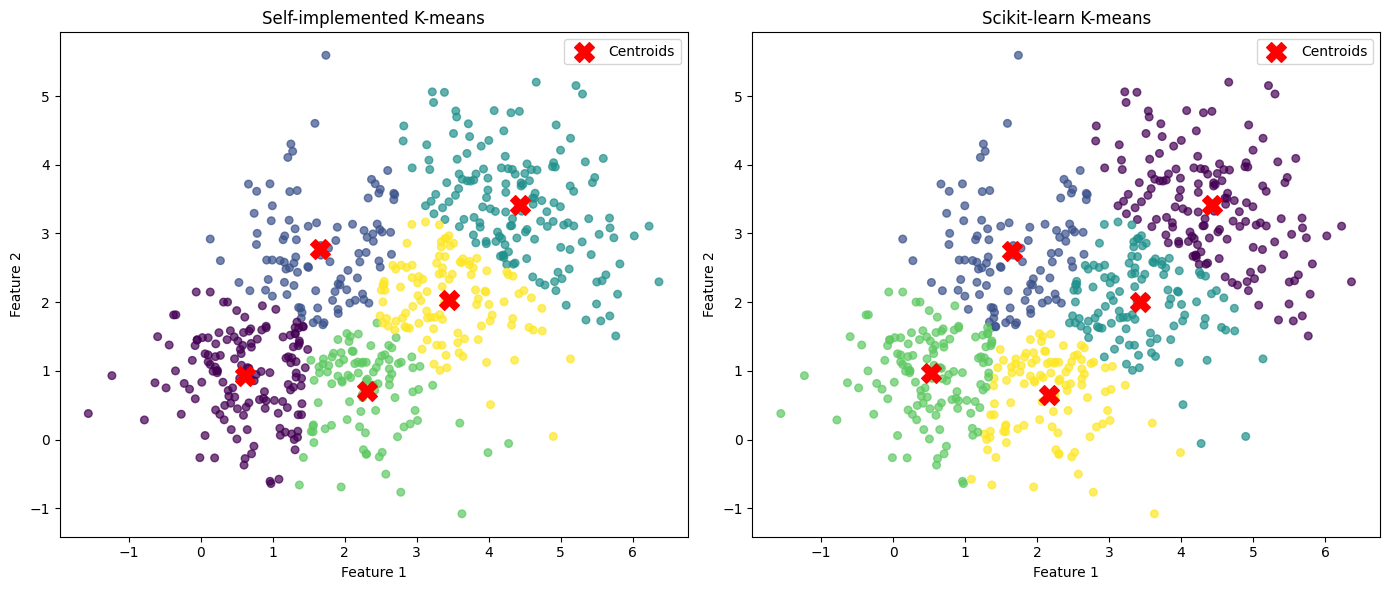

In [22]:
#2 Compare the k-means you self-implemented with Scikit-learn's K-means algorithm
from sklearn.cluster import KMeans as SKKMeans
import matplotlib.pyplot as plt

self_kmeans = KMeans(n_clusters = 5, max_iter = 300, random_state=0)
self_kmeans.fit(X)
self_cluster_labels = self_kmeans.labels
self_centroids = self_kmeans.centers


sk_kmeans = SKKMeans(n_clusters = 5)
sk_kmeans.fit(X)
sk_cluster_labels = sk_kmeans.labels_          
sk_centroids = sk_kmeans.cluster_centers_

# Create subplots
plt.figure(figsize=(14, 6))

# Plot for self-implemented K-means
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=self_cluster_labels, s=30, cmap='viridis', alpha=0.7)
plt.scatter(self_centroids[:, 0], self_centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('Self-implemented K-means', fontsize=12)
plt.xlabel('Feature 1', fontsize=10)
plt.ylabel('Feature 2', fontsize=10)
plt.legend()

# Plot for scikit-learn's K-means
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=sk_cluster_labels, s=30, cmap='viridis', alpha=0.7)
plt.scatter(sk_centroids[:, 0], sk_centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('Scikit-learn K-means', fontsize=12)
plt.xlabel('Feature 1', fontsize=10)
plt.ylabel('Feature 2', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
#3 Calculate the cluster metrics for the current clustering results.  
# ARI
ari = adjusted_rand_index(true_labels, self_cluster_labels)
print(ari)

# # Fowlkes-Mallows Index
fmi = fowlkes_mallows(true_labels, self_cluster_labels)
print(fmi)

# # Adjusted Mutual Information
ami = adjusted_mutual_info(true_labels, self_cluster_labels)
print(ami)

# # V-measure
v_score = v_measure(true_labels, self_cluster_labels, beta=1.0) 
print(v_score)

# # Silhouette Coefficient
sil_score = silhouette(X, self_cluster_labels) 
print(sil_score)

# # Calinski-Harabaz Index
ch_score = calinski_harabaz(X, self_cluster_labels)
print(ch_score)

# # Davies-Bouldin Index
db_score = davies_bouldin(X, self_cluster_labels)
print(db_score)

0.35183867936770313
0.5315389397458433
0.39347900002084607
0.3898605235685585
0.3380507982424909
564.3723729945749
0.915628287463943


**Question 4.** Manual Calculation of 1D k-means Algorithm  

* Dataset: $X = \{2, 4, 10, 12, 3, 20, 30, 11, 25\}$
* Initial Cluster Centers: $\mu_1 = 4, \mu_2 = 12, \mu_3 = 25$  

**Task**  
1.Perform the **first two full iterations** of the k-means algorithm (including both assignment and update steps).  
2.Calculate **cluster assignments** and **new centroids** for each iteration.  
3.**Determine if convergence is achieved** after the second iteration (terminate early if converged).

## First Iteration

### Step 1: Assignment
Calculate distances from each data point to all centroids and assign each point to the nearest centroid.

| Data Point | Distance to μ₁ (4) | Distance to μ₂ (12) | Distance to μ₃ (25) | Closest Centroid |
|------------|---------------------|----------------------|----------------------|-------------------|
| 2          | 2                   | 10                   | 23                   | μ₁                |
| 4          | 0                   | 8                    | 21                   | μ₁                |
| 10         | 6                   | 2                    | 15                   | μ₂                |
| 12         | 8                   | 0                    | 13                   | μ₂                |
| 3          | 1                   | 9                    | 22                   | μ₁                |
| 20         | 16                  | 8                    | 5                    | μ₃                |
| 30         | 26                  | 18                   | 5                    | μ₃                |
| 11         | 7                   | 1                    | 14                   | μ₂                |
| 25         | 21                  | 13                   | 0                    | μ₃                |

**Cluster Assignments**:
- **Cluster 1 (μ₁)**: {2, 4, 3}
- **Cluster 2 (μ₂)**: {10, 12, 11}
- **Cluster 3 (μ₃)**: {20, 30, 25}

### Step 2: Update
Calculate new centroids by taking the mean of each cluster.

- **New μ₁**: (2 + 4 + 3) / 3 = 3
- **New μ₂**: (10 + 12 + 11) / 3 = 11
- **New μ₃**: (20 + 30 + 25) / 3 ≈ 25

**Updated Centroids**: μ₁ = 3, μ₂ = 11, μ₃ = 25

## Second Iteration

### Step 1: Assignment
Calculate distances from each data point to the new centroids and reassign.

| Data Point | Distance to μ₁ (3) | Distance to μ₂ (11) | Distance to μ₃ (25) | Closest Centroid |
|------------|---------------------|----------------------|----------------------|-------------------|
| 2          | 1                   | 9                    | 23                   | μ₁                |
| 4          | 1                   | 7                    | 21                   | μ₁                |
| 10         | 7                   | 1                    | 15                   | μ₂                |
| 12         | 9                   | 1                    | 13                   | μ₂                |
| 3          | 0                   | 8                    | 22                   | μ₁                |
| 20         | 17                  | 9                    | 5                    | μ₃                |
| 30         | 27                  | 19                   | 5                    | μ₃                |
| 11         | 8                   | 0                    | 14                   | μ₂                |
| 25         | 22                  | 14                   | 0                    | μ₃                |

**Cluster Assignments**:
- **Cluster 1 (μ₁)**: {2, 4, 3}
- **Cluster 2 (μ₂)**: {10, 12, 11}
- **Cluster 3 (μ₃)**: {20, 30, 25}

### Step 2: Update
Calculate new centroids by taking the mean of each cluster.

- **New μ₁**: (2 + 4 + 3) / 3 = 3
- **New μ₂**: (10 + 12 + 11) / 3 = 11
- **New μ₃**: (20 + 30 + 25) / 3 ≈ 25

**Updated Centroids**: μ₁ = 3, μ₂ = 11, μ₃ = 25

## Convergence Check
After the second iteration, the centroids remain the same as in the first iteration:
- μ₁ = 3, μ₂ = 11, μ₃ = 25

Since the centroids did not change between the first and second iterations, **convergence is achieved**. The algorithm can terminate early.

**Question 5.**   

Please fill the following code to finish the function performing k-means++ (smart initialization for kmeans).
Test your algorithm as instructed in Question 3.

In [28]:
import numpy as np
import random

def SmartInitialize(x, K):
    # x is a n*m matrix, where n is the number of samples, m is the dimension of features
    # K is the selected number of centers
    # step 1: Choose the first center randomly from the data points
    c1_idx = int(np.random.uniform(0, len(x)))
    center = x[c1_idx].reshape(-1, 1)
    
    k = 1
    n = x.shape[0]

    while k < K:
        d2 = []
        for i in range(n):
            # for each remaining point, calculate its squared distances to the existing centers
            distance = np.sum(np.power(center-x[i, :], 2), axis=1)
            # find and save the its nearest distance to the existing centers
            d2.append(np.min(distance))
        # select the next center with probability proportional to the distances between remaining points to the existing centers
        sum_all = np.sum(d2)
        sum_all = sum_all * random.rand()
        for j, d in enumerate(d2):
            sum_all = sum_all - d
            if sum_all > 0:
                continue
            new_c_idx = j
            break
        center = np.vstack([center, x[new_c_idx]])
        k += 1
    
    return center